In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

print("Libraries imported successfully!")



Libraries imported successfully!


In [4]:

# Load the Breast Cancer Wisconsin dataset

cancer = load_breast_cancer()

# Convert the measurements into a DataFrame
df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Add the diagnosis labels
df["diagnosis"] = [
    cancer.target_names[i]
    for i in cancer.target
]

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


Dataset loaded successfully!
Dataset shape: (569, 31)


In [5]:

# Display the first five rows of the dataset
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [6]:

# Count how many observations belong to each diagnosis
df["diagnosis"].value_counts()


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

In [7]:

# Examine the dataset structure
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [8]:

# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("Total missing values:", missing_values.sum())


Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64
Total missing values: 0


In [9]:

# Check for completely duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [10]:

# Summary statistics for numerical variables
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [11]:

# Select three measurements of interest
features = [
    "mean radius",
    "mean texture",
    "mean area"
]

# Display summary statistics for these measurements
df[features].describe().round(2)


,mean radius,mean texture,mean area
count,569.00,569.00,569.00
mean,14.13,19.29,654.89
std,3.52,4.30,351.91
min,6.98,9.71,143.50
25%,11.70,16.17,420.30
50%,13.37,18.84,551.10
75%,15.78,21.80,782.70
max,28.11,39.28,2501.00


In [12]:

# Compare mean measurements between diagnosis groups
group_means = (
    df.groupby("diagnosis")[features]
    .mean()
    .round(2)
)

display(group_means)


,mean radius,mean texture,mean area
diagnosis,,,
benign,12.15,17.91,462.79
malignant,17.46,21.60,978.38


## Initial Data Exploration

The dataset contains 569 observations with 30 numerical measurements and one diagnostic label.

The initial quality checks examine missing values and duplicate observations. The dataset contains no missing values.

Descriptive statistics were calculated to explore the distribution of numerical features. Measurements including mean radius, mean texture and mean area were selected for further investigation.

Group-level comparisons suggest differences in nuclear measurements between benign and malignant cases. Further visualisation and statistical analysis will be required to investigate these patterns.

These findings are exploratory and should not be interpreted as clinically validated diagnostic conclusions.


In [13]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for our graphs
sns.set_theme(style="white", context="notebook")

# Colours for our diagnosis groups
colours = {
    "benign": "#4C91C7",
    "malignant": "#E66B65"
}

print("Visualisation libraries loaded!")


Visualisation libraries loaded!


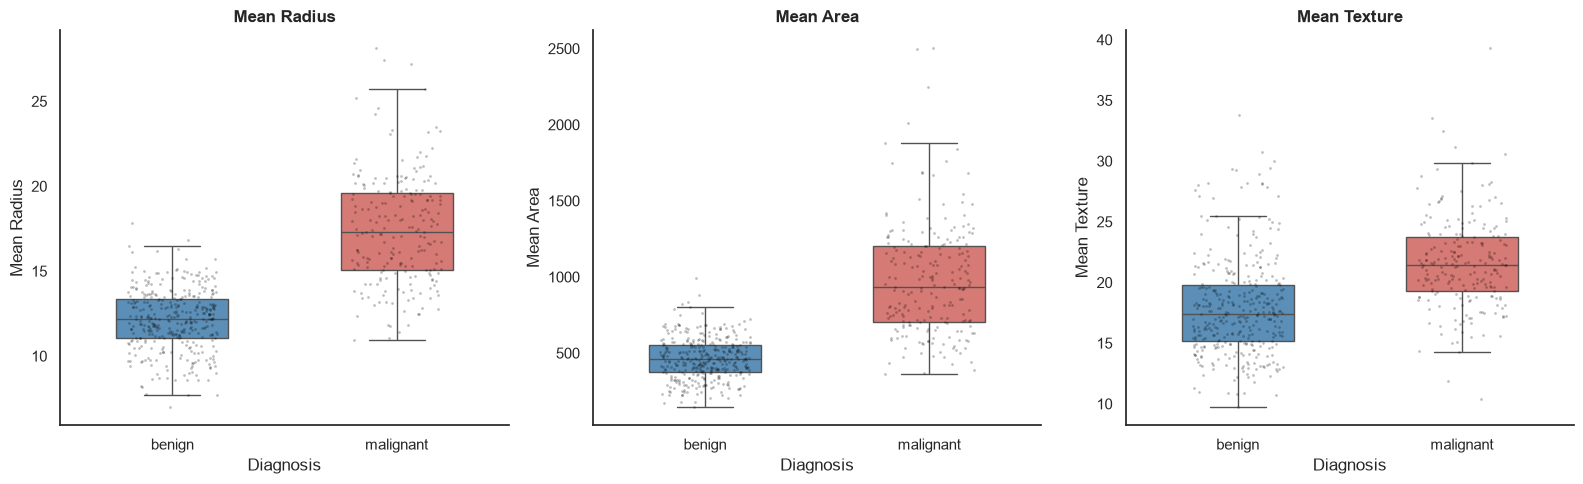

In [16]:

# Measurements to compare
features = ["mean radius", "mean area", "mean texture"]

# Create three graphs side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, features):

    # Create boxplots
    sns.boxplot(
        data=df,
        x="diagnosis",
        y=feature,
        hue="diagnosis",
        order=["benign", "malignant"],
        hue_order=["benign", "malignant"],
        palette=colours,
        legend=False,
        width=0.5,
        showfliers=False,
        ax=ax
    )

    # Add individual observations
    sns.stripplot(
        data=df,
        x="diagnosis",
        y=feature,
        order=["benign", "malignant"],
        color="black",
        alpha=0.25,
        size=2,
        jitter=0.2,
        ax=ax
    )

    ax.set_title(feature.title(), fontweight="bold")
    ax.set_xlabel("Diagnosis")
    ax.set_ylabel(feature.title())

sns.despine()
plt.tight_layout()
plt.show()



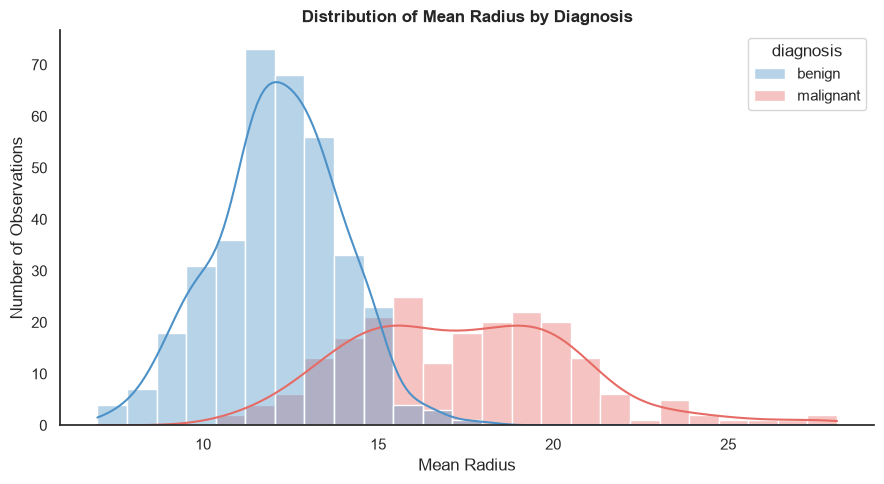

In [17]:

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="mean radius",
    hue="diagnosis",
    hue_order=["benign", "malignant"],
    palette=colours,
    kde=True,
    bins=25,
    alpha=0.4
)

plt.title("Distribution of Mean Radius by Diagnosis",
          fontweight="bold")
plt.xlabel("Mean Radius")
plt.ylabel("Number of Observations")

sns.despine()
plt.tight_layout()
plt.show()


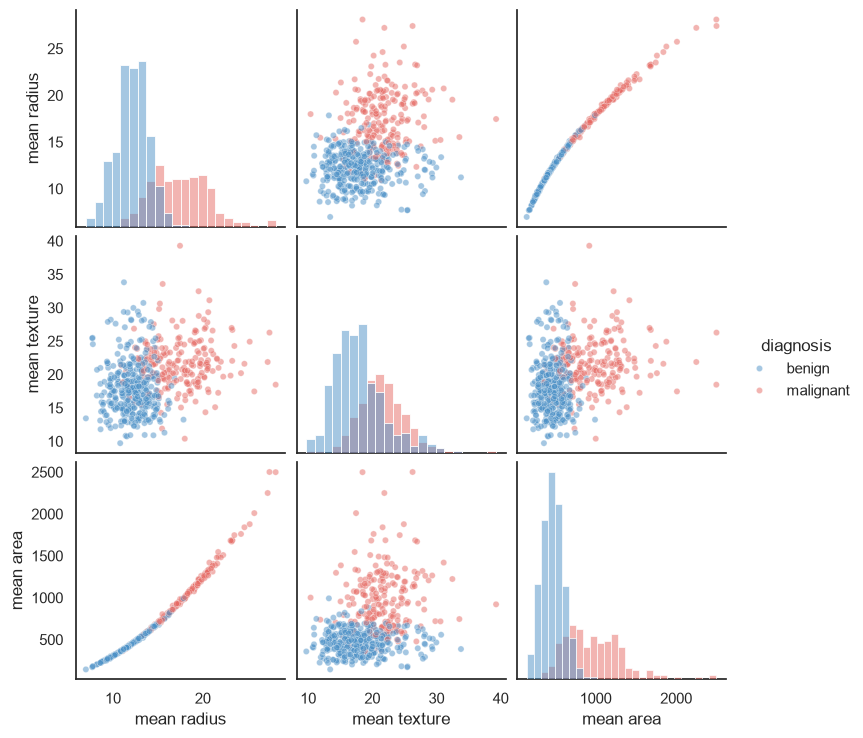

In [18]:

sns.pairplot(
    data=df,
    vars=["mean radius", "mean texture", "mean area"],
    hue="diagnosis",
    hue_order=["benign", "malignant"],
    palette=colours,
    diag_kind="hist",
    plot_kws={"alpha": 0.5, "s": 20}
)

plt.show()


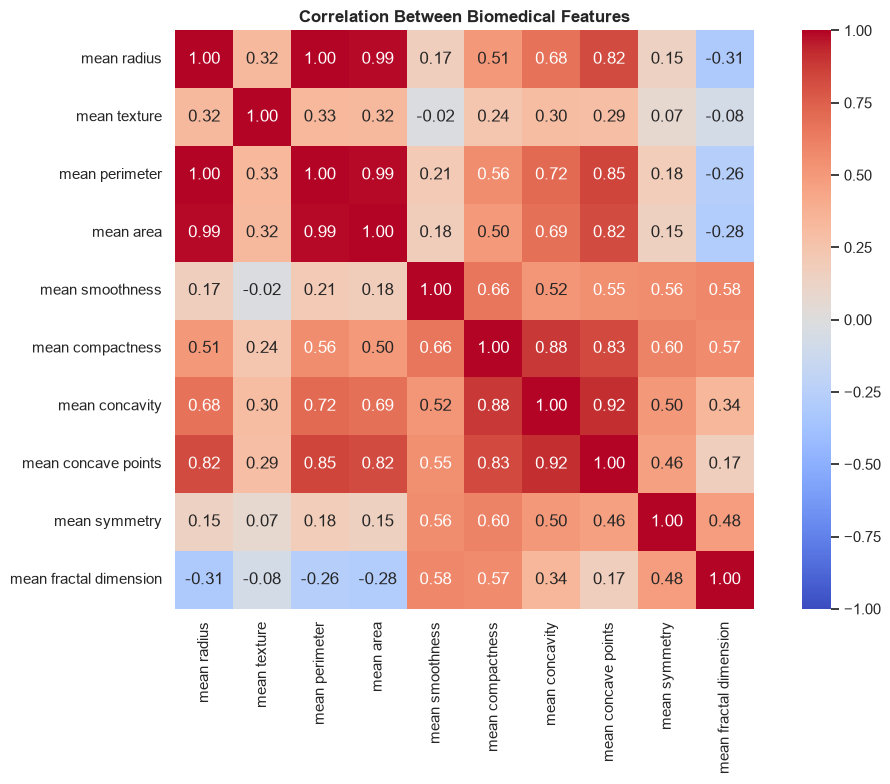

In [19]:

# Select the first 10 numerical measurements
selected_features = list(cancer.feature_names[:10])

# Calculate Pearson correlations
correlation_matrix = df[selected_features].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Between Biomedical Features",
          fontweight="bold")

plt.tight_layout()
plt.show()


In [20]:
import os

os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/diagnosis_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

In [21]:

from scipy import stats

print("Statistical analysis library loaded!")


Statistical analysis library loaded!


In [22]:

# Extract mean radius measurements for each diagnosis

benign_radius = df.loc[
    df["diagnosis"] == "benign", "mean radius"
]

malignant_radius = df.loc[
    df["diagnosis"] == "malignant", "mean radius"
]

print("Benign observations:", len(benign_radius))
print("Malignant observations:", len(malignant_radius))


Benign observations: 357
Malignant observations: 212


In [23]:

# Welch's independent-samples t-test

t_statistic, p_value = stats.ttest_ind(
    benign_radius,
    malignant_radius,
    equal_var=False
)

print("T-statistic:", round(t_statistic, 3))
print("P-value:", p_value)


T-statistic: -22.209
P-value: 1.6844591259582815e-64


A Welch's independent-samples t-test identified a statistically significant difference in mean radius between benign and malignant samples (t = −22.21, p < 0.001).

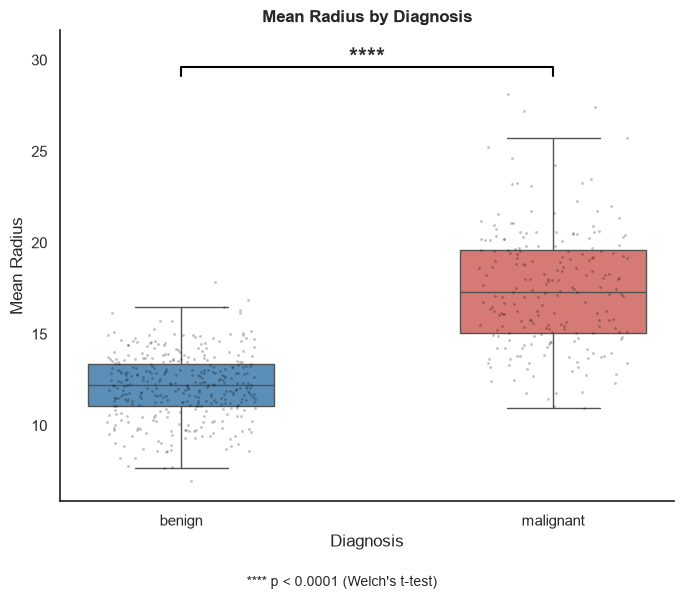

In [24]:

# Boxplot with statistical significance annotation

fig, ax = plt.subplots(figsize=(7, 6))

sns.boxplot(
    data=df,
    x="diagnosis",
    y="mean radius",
    hue="diagnosis",
    order=["benign", "malignant"],
    hue_order=["benign", "malignant"],
    palette=colours,
    legend=False,
    showfliers=False,
    width=0.5,
    ax=ax
)

sns.stripplot(
    data=df,
    x="diagnosis",
    y="mean radius",
    order=["benign", "malignant"],
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.2,
    ax=ax
)

# Position the annotation above the data
y_max = df["mean radius"].max()
y = y_max + 1
h = 0.5

# Draw significance bracket
ax.plot(
    [0, 0, 1, 1],
    [y, y + h, y + h, y],
    color="black",
    linewidth=1.5
)

# Add significance label
ax.text(
    0.5,
    y + h + 0.2,
    "****",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylim(top=y + h + 2)
ax.set_title("Mean Radius by Diagnosis", fontweight="bold")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Mean Radius")

# Explain the annotation
fig.text(
    0.5, 0.01,
    "**** p < 0.0001 (Welch's t-test)",
    ha="center",
    fontsize=10
)

sns.despine()
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


## Statistical Analysis: Mean Radius

A Welch's independent-samples t-test was performed to compare mean radius measurements between benign and malignant diagnostic groups.

The analysis identified a statistically significant difference between groups (t = -22.21, p < 0.001).

The negative t-statistic indicates that the benign group had a lower sample mean radius than the malignant group.

**Limitations:** This is an exploratory analysis of an existing diagnostic dataset. Statistical significance does not necessarily indicate clinical utility. The analysis also does not establish causation.